# Part1:Omar

# Import library and Functions.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor 
from sklearn.preprocessing import MinMaxScaler

#     تسلسل الخطوات من معالجه ك تسلسل المحاضرات 

# Read the DataSet file

In [6]:
df=pd.read_csv('diamonds.csv')
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [10]:
print(df["carat"].value_counts())
print(df["cut"].value_counts())
print(df["color"].value_counts())
print(df["clarity"].value_counts())
print(df["price"].value_counts())
print(df["x"].value_counts())
print(df["y"].value_counts())
print(df["z"].value_counts())
print(df["depth"].value_counts())
print(df["table"].value_counts())

carat
0.30    2604
0.31    2249
1.01    2242
0.70    1981
0.32    1840
        ... 
3.02       1
3.65       1
3.50       1
3.22       1
3.11       1
Name: count, Length: 273, dtype: int64
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64
price
605      132
802      127
625      126
828      125
776      124
        ... 
8816       1
14704      1
14699      1
14698      1
9793       1
Name: count, Length: 11602, dtype: int64
x
4.37     448
4.34     437
4.33     429
4.38     428
4.32     425
        ... 
10.74      1
9.36       1
8.89       1
10.23      1
10.00      1
Name: count, Length: 554, dtype: int64
y
4.34     437
4.37     435
4.35     425
4.33     421
4.32

# Displaying objects in Dataset

In [12]:
df.describe(include=[object])

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


# Visualizing object in dataset

# 1-lineplot
<p>سوف تعرض كيف تتغير القيم عبر متغير مستمر الهدف وهو السعر</p>

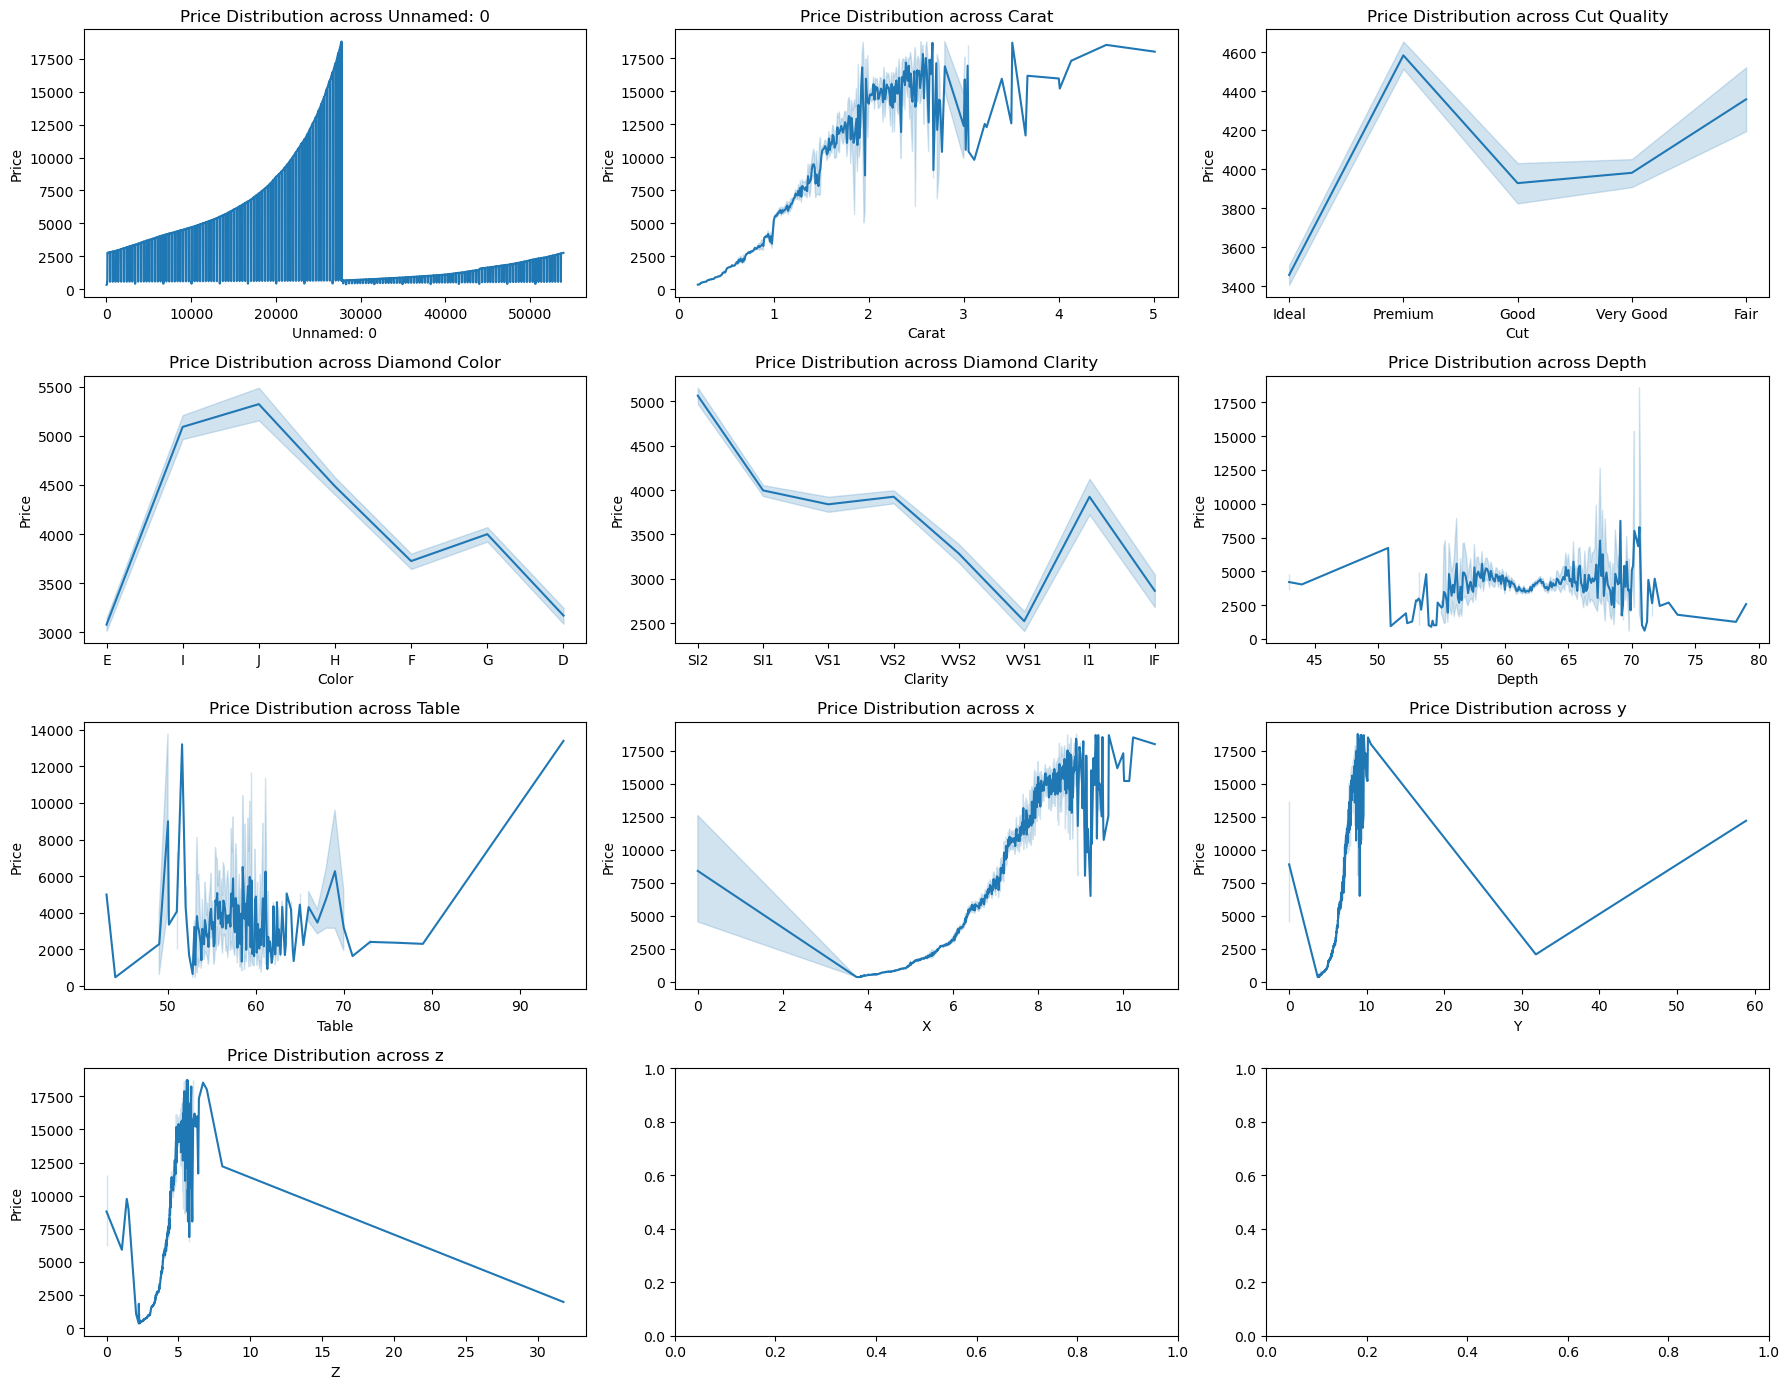

In [21]:
columns = ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
titles = ['Price Distribution across Unnamed: 0', 'Price Distribution across Carat', 'Price Distribution across Cut Quality', 'Price Distribution across Diamond Color', 'Price Distribution across Diamond Clarity', 'Price Distribution across Depth', 'Price Distribution across Table', 'Price Distribution across x', 'Price Distribution across y', 'Price Distribution across z']

fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.lineplot(data=df, x=col, y='price', ax=axs[i//3, i%3])
    axs[i//3, i%3].set_title(titles[i])
    axs[i//3, i%3].set_xlabel(col.capitalize())
    axs[i//3, i%3].set_ylabel('Price')

fig.tight_layout()
plt.show()


# 2-scatterplot
<p>سوف نعرض البيانات بشكل مرئي لكي نفهم توزيع البيانات مع السعر</p>

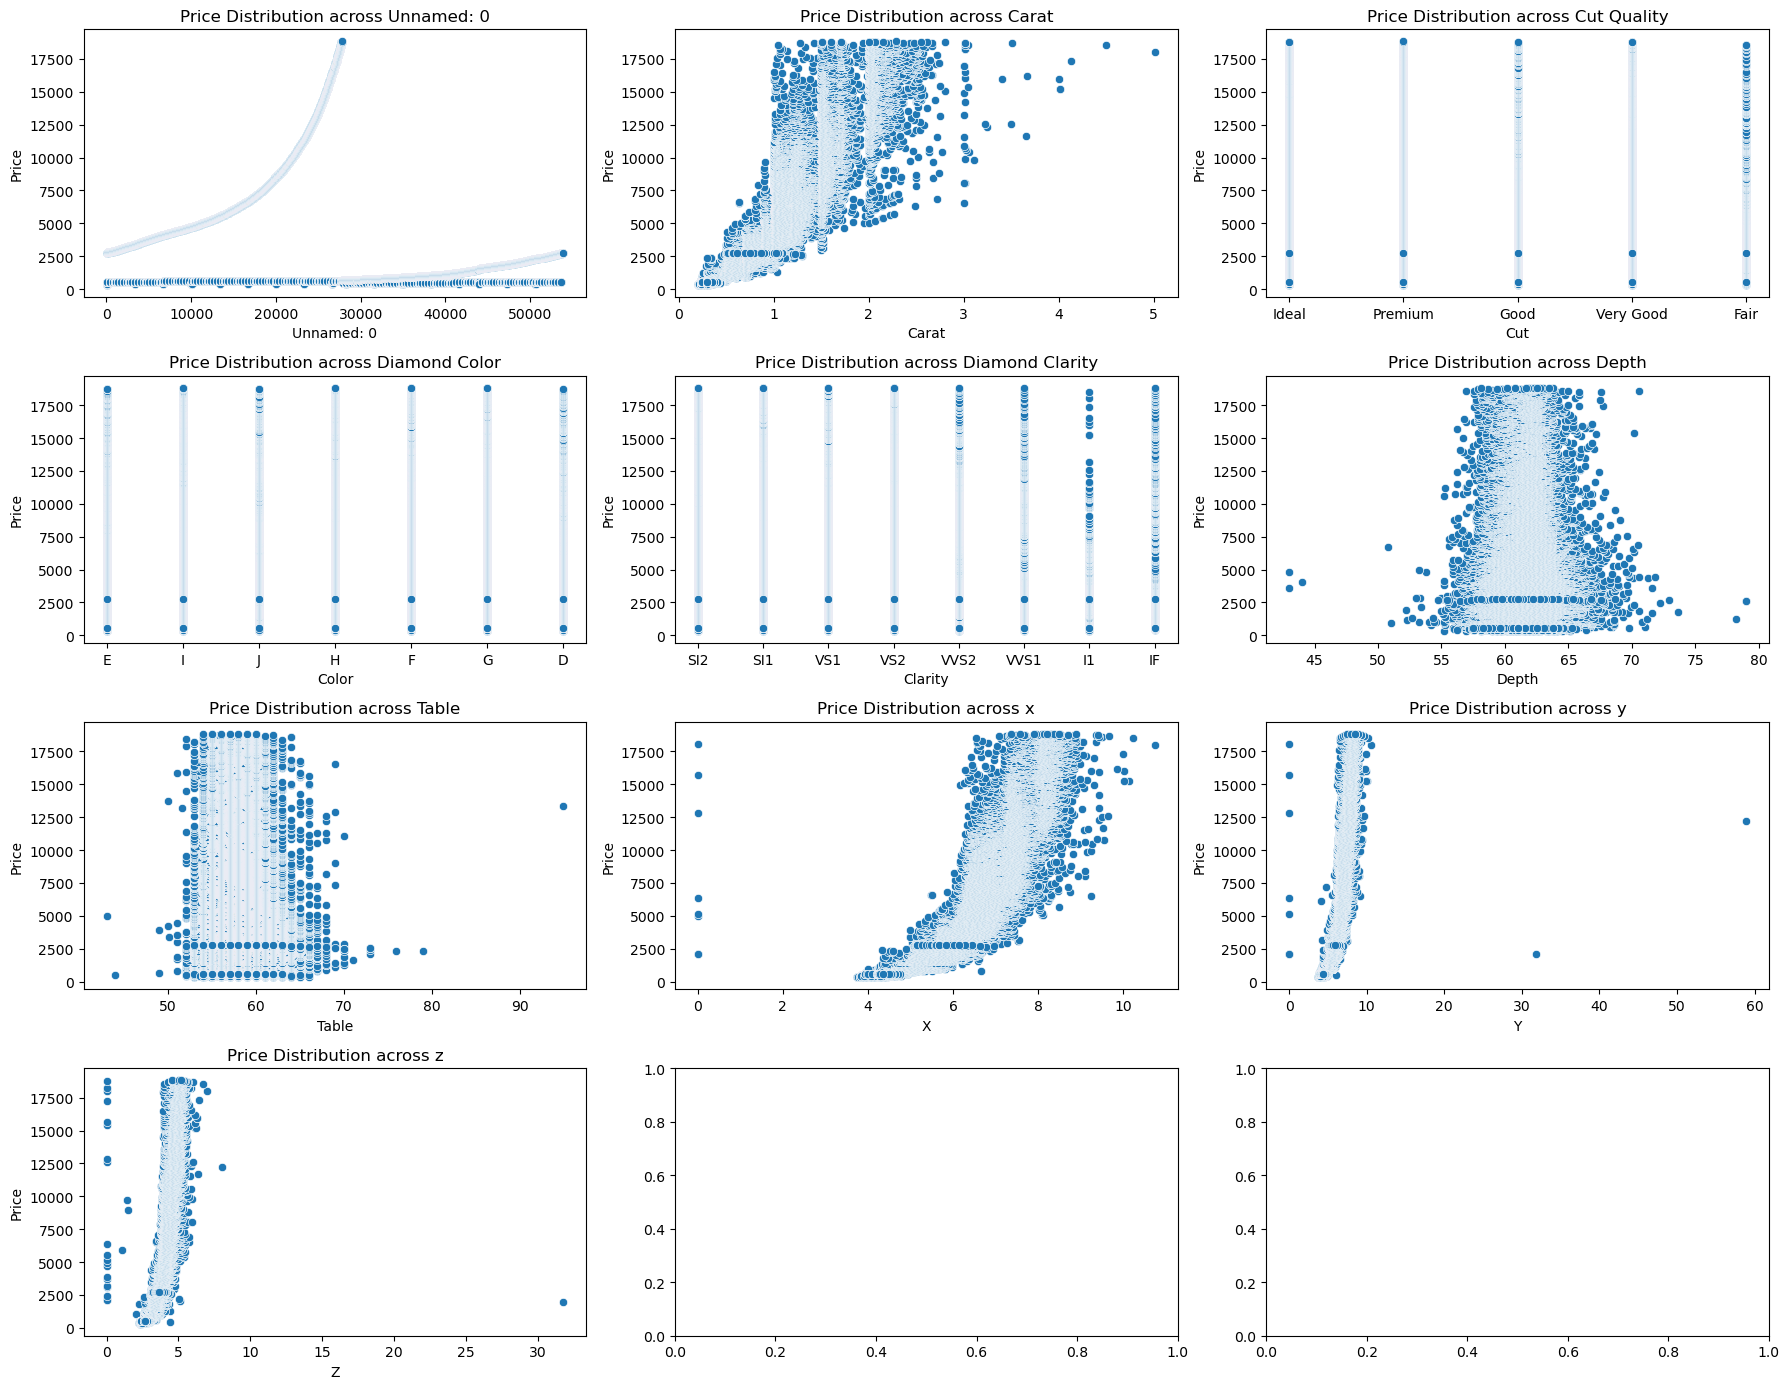

In [24]:
columns = ['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
titles = ['Price Distribution across Unnamed: 0', 'Price Distribution across Carat', 'Price Distribution across Cut Quality', 'Price Distribution across Diamond Color', 'Price Distribution across Diamond Clarity', 'Price Distribution across Depth', 'Price Distribution across Table', 'Price Distribution across x', 'Price Distribution across y', 'Price Distribution across z']

fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.scatterplot(data=df, x=col, y='price', ax=axs[i//3, i%3])
    axs[i//3, i%3].set_title(titles[i])
    axs[i//3, i%3].set_xlabel(col.capitalize())
    axs[i//3, i%3].set_ylabel('Price')

fig.tight_layout()
plt.show()


# 3-barplot
<p>سوف نستخدمه لعرض عدد العينات لكل فئه من الفئه التصنيفيه يهمنا في العامود الغير مستمر.قمنا بوضعه لجميع الاعمده</p>

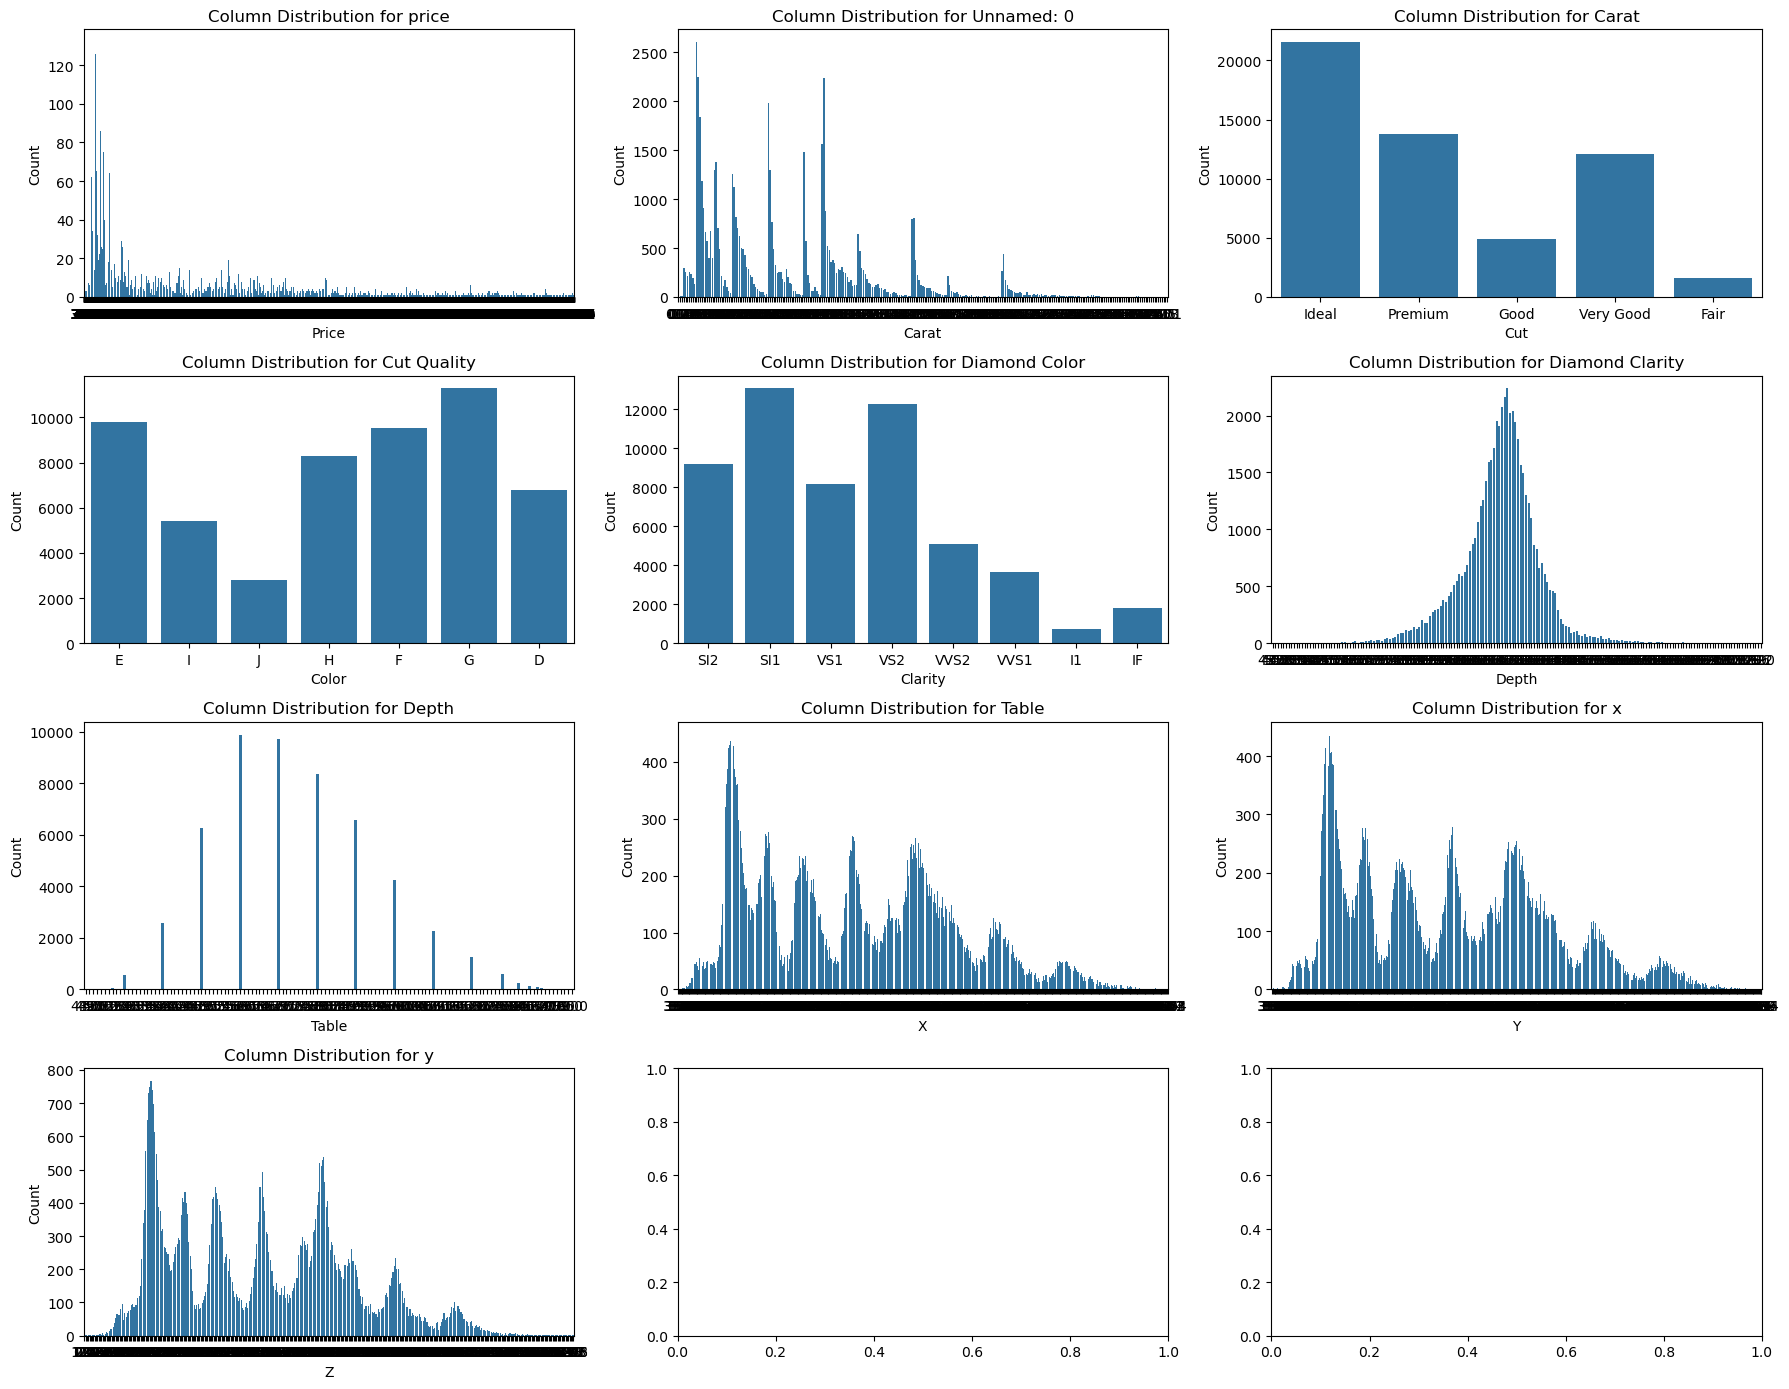

In [26]:
columns = ['price', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
titles = ['Column Distribution for price','Column Distribution for Unnamed: 0', 'Column Distribution for Carat', 'Column Distribution for Cut Quality', 'Column Distribution for Diamond Color', 'Column Distribution for Diamond Clarity', 'Column Distribution for Depth', 'Column Distribution for Table', 'Column Distribution for x', 'Column Distribution for y', 'Column Distribution for z']

fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.countplot(data=df, x=col, ax=axs[i//3, i%3])
    axs[i//3, i%3].set_title(titles[i])
    axs[i//3, i%3].set_xlabel(col.capitalize())
    axs[i//3, i%3].set_ylabel('Count')

fig.tight_layout()
plt.show()


# 4-histogram
 <p>يستخدم لمعرفه توزيع القيم في كل عامود ويمكن استخدامه في القيم المستمره ويمكن استنتاج القيم الشاذه منه</p>

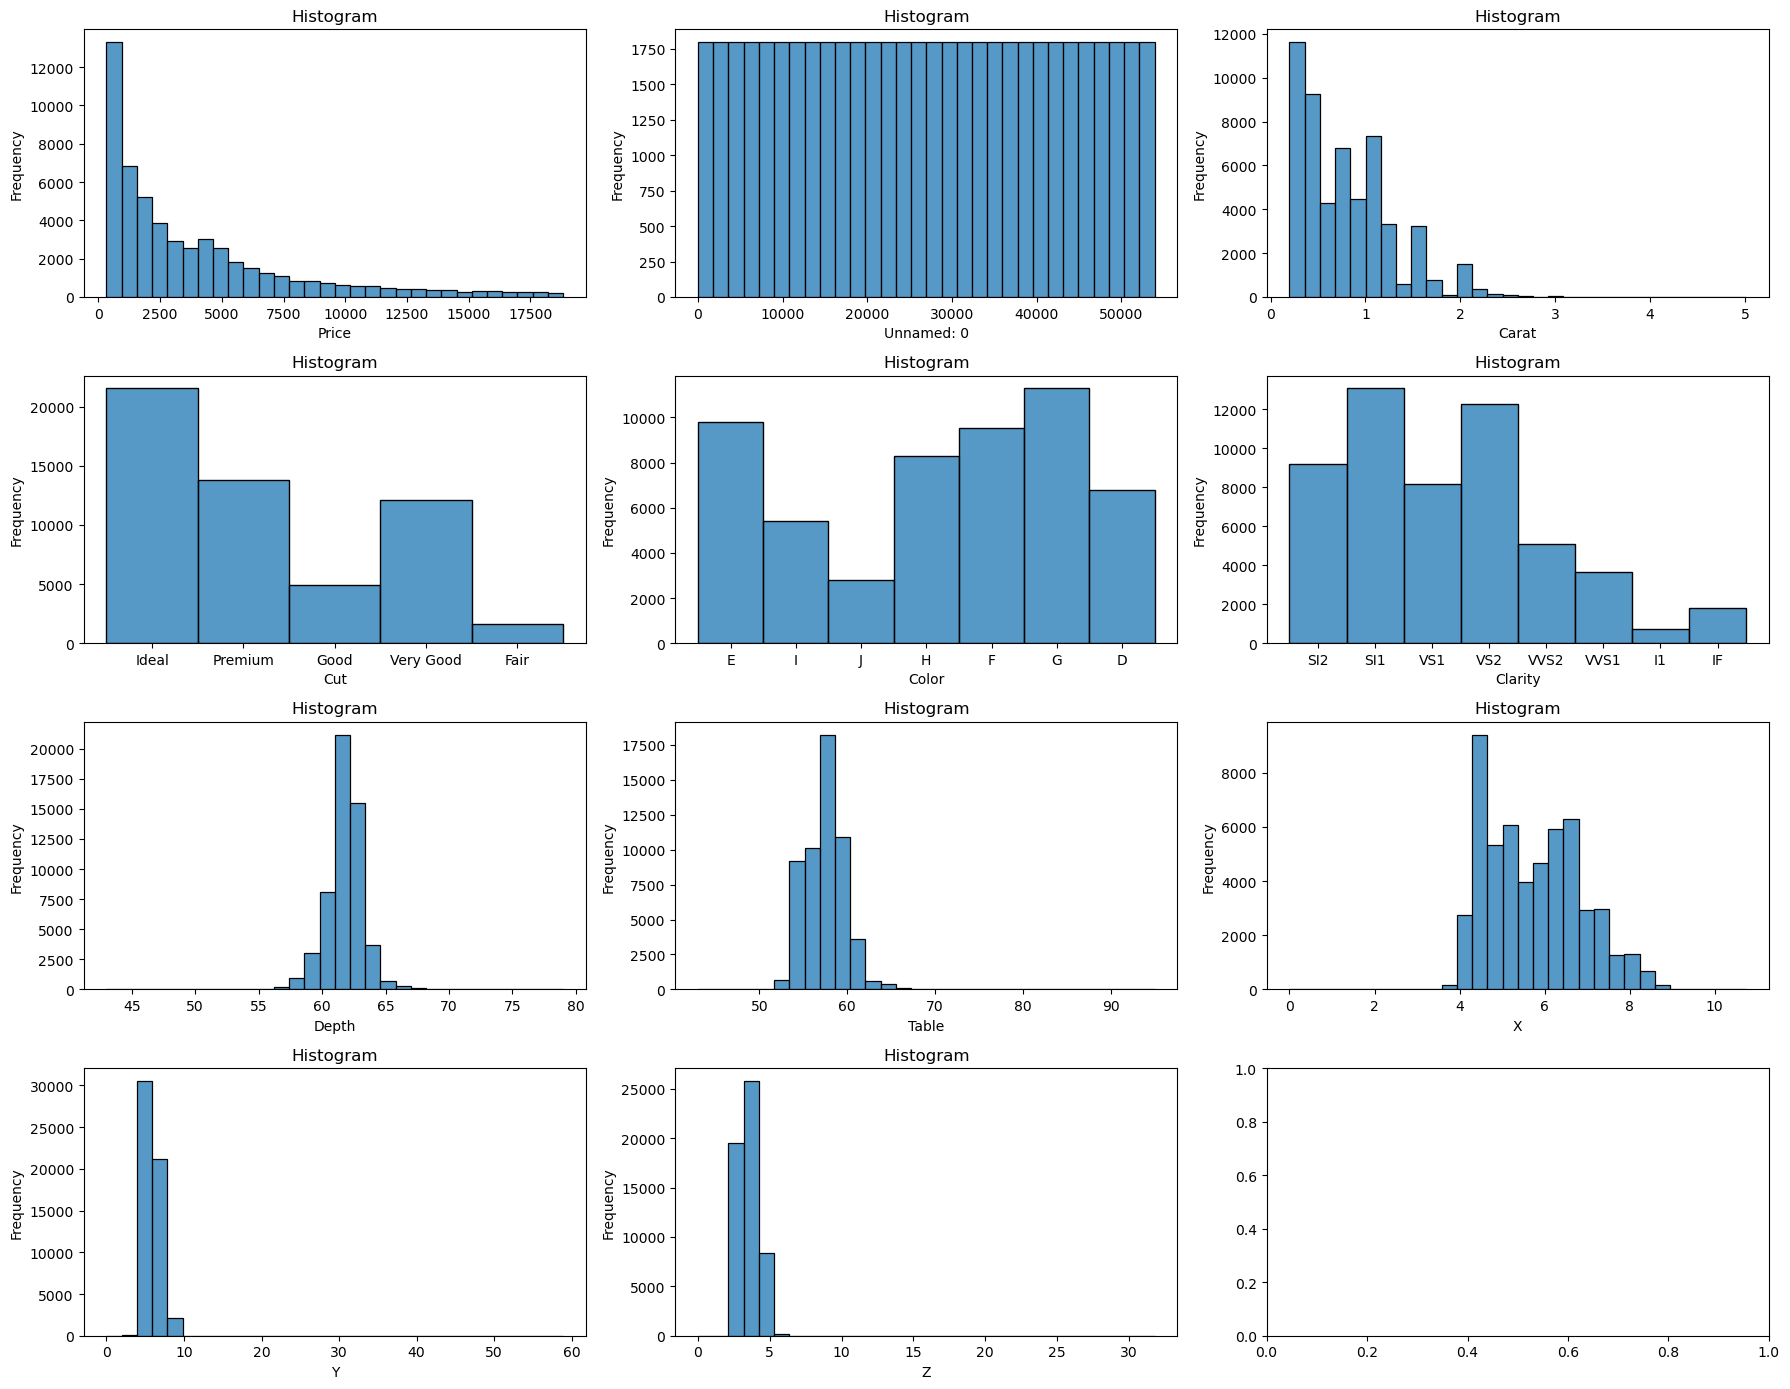

In [28]:
columns = ['price', 'Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
titles = ['Histogram']

fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, ax=axs[i//3, i%3], bins=30)
    axs[i//3, i%3].set_title(titles[0])
    axs[i//3, i%3].set_xlabel(col.capitalize())
    axs[i//3, i%3].set_ylabel('Frequency')

fig.tight_layout()
plt.show()


# 5-boxplot
<p>يستخدم لتحديد القيم الشاذه</p>

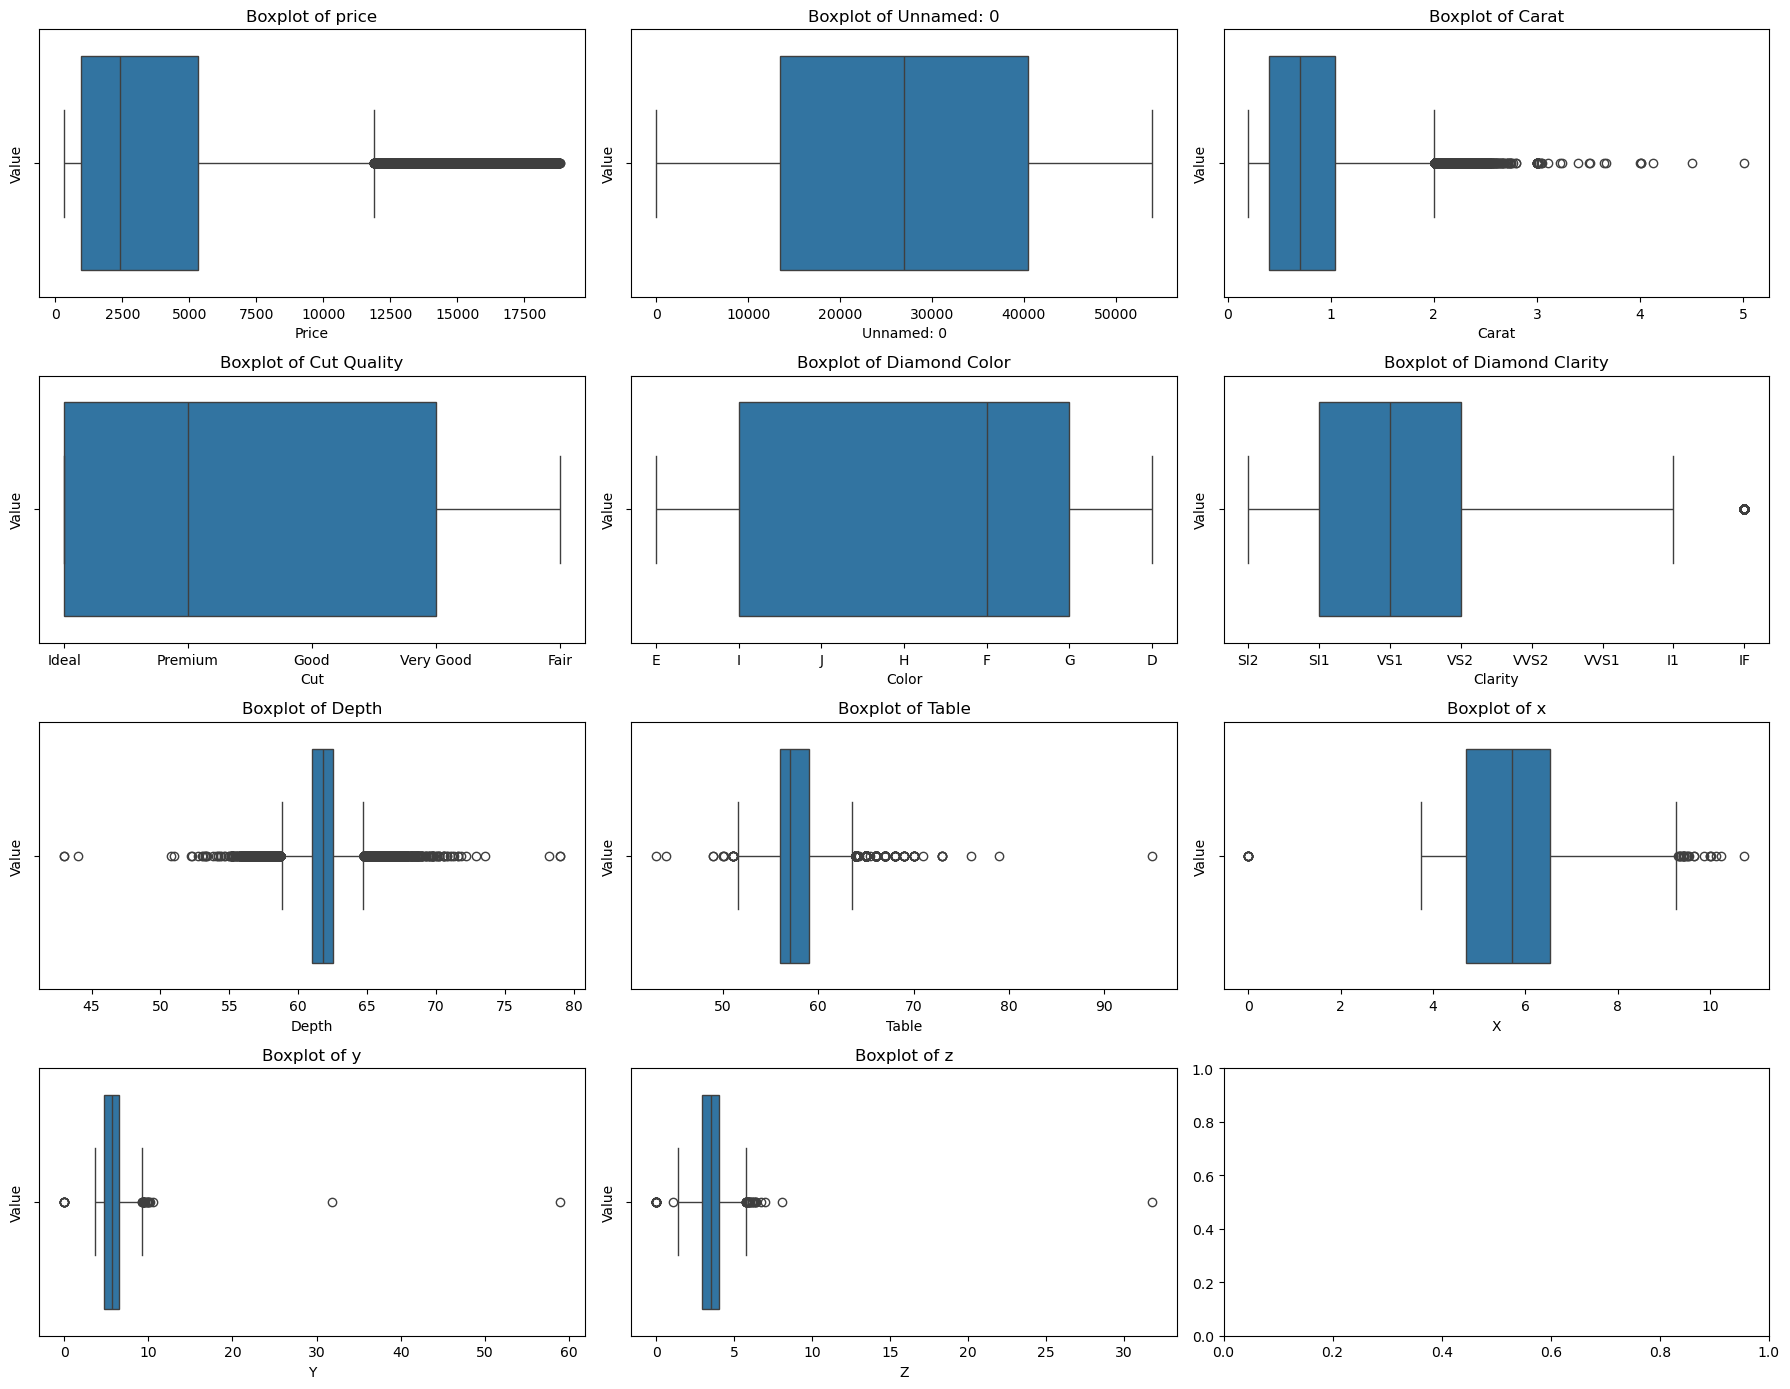

In [30]:
columns = ['price', 'Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
titles = ['Boxplot of price', 'Boxplot of Unnamed: 0', 'Boxplot of Carat', 'Boxplot of Cut Quality', 'Boxplot of Diamond Color', 'Boxplot of Diamond Clarity', 'Boxplot of Depth', 'Boxplot of Table', 'Boxplot of x', 'Boxplot of y', 'Boxplot of z']

fig, axs = plt.subplots(4, 3, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.boxplot(data=df, x=df[col], ax=axs[i//3, i%3])
    axs[i//3, i%3].set_title(titles[i])
    axs[i//3, i%3].set_xlabel(col.capitalize())
    axs[i//3, i%3].set_ylabel('Value')

fig.tight_layout()
plt.show()


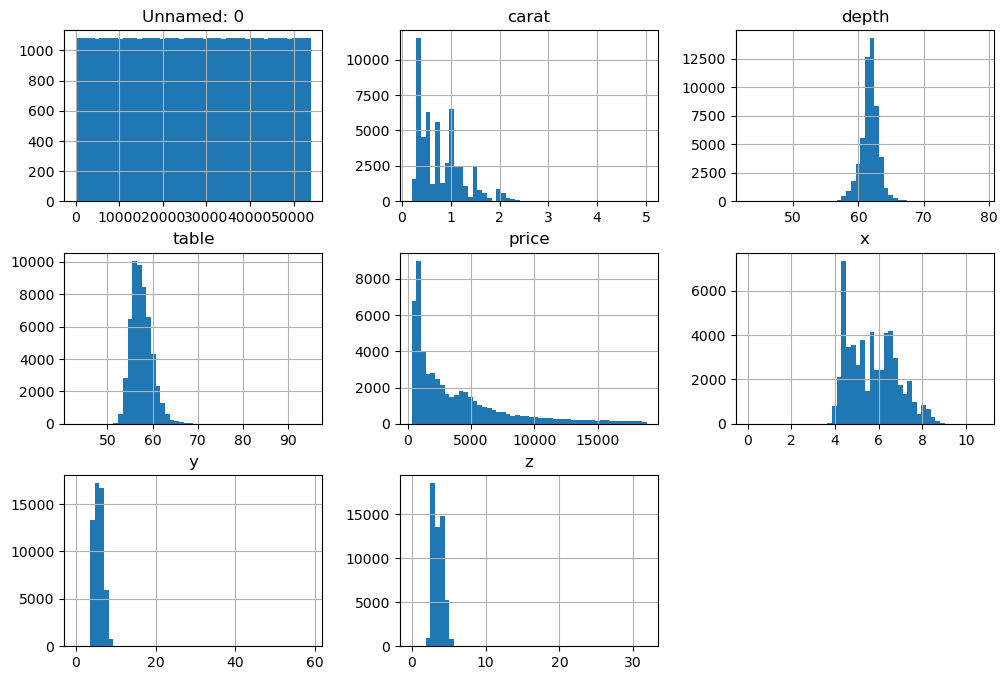

In [31]:
df.hist(bins=50, figsize=(12,8))
plt.show()

# Handle missing values

<BarContainer object of 11 artists>

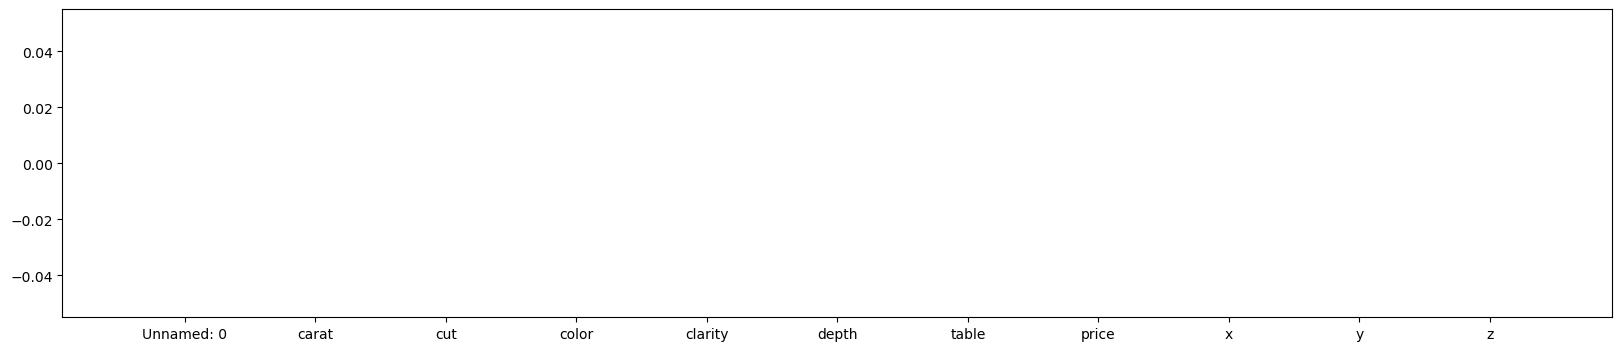

In [33]:
plt.figure(figsize=(20, 4))
plt.bar(df.columns, df.isnull().sum())
#We note that there are no missing values.
#If there are any, the numbers will be processed using the arithmetic mean,
#df1 = df2.fillna(df.columns.mean()) 
#and the texts using the most repeated value.

# Outliers processing
<p>The IsolationForest algorithm gave better results than determining (Lower Bound and Upper Bound).</p>

In [35]:
# calculate summary statistics 
columns_to_plot = ['Unnamed: 0', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z']
d = df.select_dtypes(include=[np.number])
df1 = pd.DataFrame()

for column in columns_to_plot:
    mean = d[column].mean() 
    std = d[column].std() 
    
    # Calculate the lower and upper bounds 
    lower_bound = mean - std * 2
    upper_bound = mean + std * 2
    
    print('Lower Bound for', column, ':', lower_bound) 
    print('Upper Bound for', column, ':', upper_bound) 
    print("-------------")
    
    # Drop the outliers
    df1[column] = d[(d[column] >= lower_bound) & (d[column] <= upper_bound)][column]


Lower Bound for Unnamed: 0 : -4172.0621938850745
Upper Bound for Unnamed: 0 : 58113.062193885075
-------------
Lower Bound for carat : -0.15008274094275997
Upper Bound for carat : 1.7459622366787628
-------------
Lower Bound for depth : 58.884162256659486
Upper Bound for depth : 64.61464753199458
-------------
Lower Bound for table : 52.9882027824041
Upper Bound for table : 61.92616503368785
-------------
Lower Bound for price : -4046.0797543793674
Upper Bound for price : 11911.679198205842
-------------
Lower Bound for x : 3.4876357181318376
Upper Bound for x : 7.974678705301606
-------------
Lower Bound for y : 3.450256606517474
Upper Bound for y : 8.018795303011633
-------------
Lower Bound for z : 2.1273360843721614
Upper Bound for z : 4.950131472172147
-------------


<BarContainer object of 8 artists>

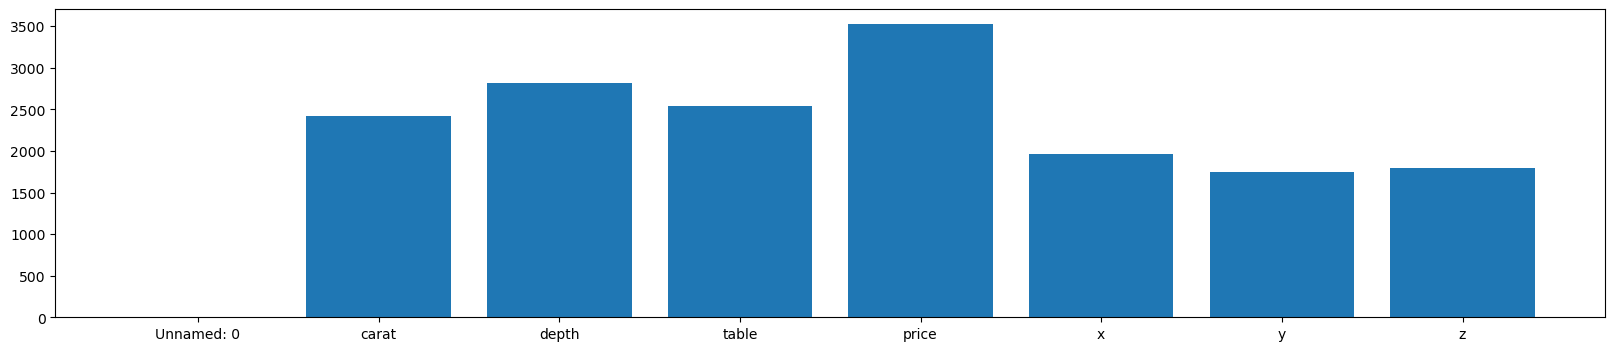

In [36]:
plt.figure(figsize=(20, 4))
plt.bar(df1.columns, df1.isnull().sum())

In [37]:
#Handle missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
imputer.fit(df1)
df1=imputer.transform(df1)
print('missing value:',df1.isnull().any(axis=1).sum())

missing value: 0


In [113]:
# التحقق من القيم الشاذه بعد معالجتها

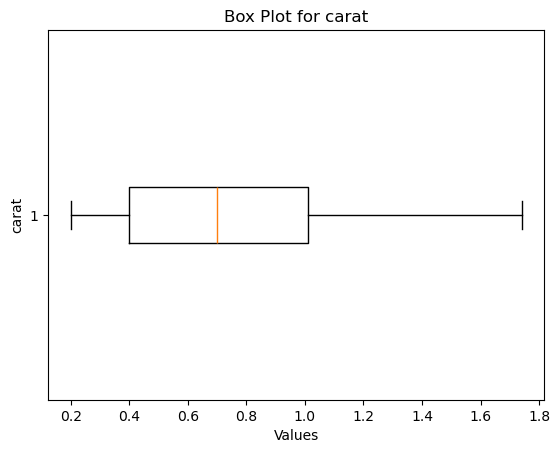

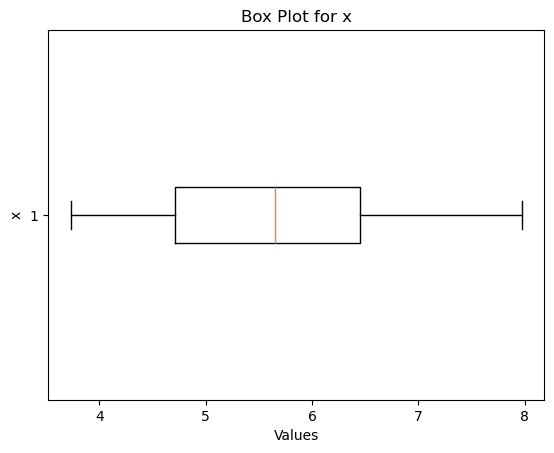

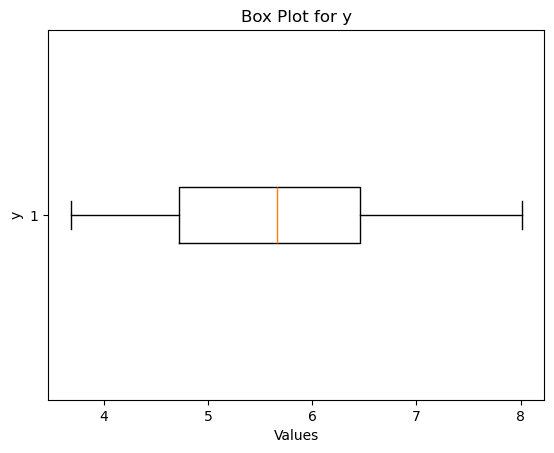

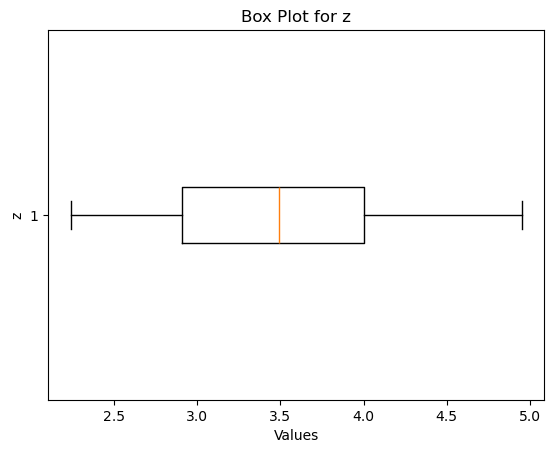

In [38]:
columns_to_plot = [ 'carat', 'x', 'y',	'z']
for column in columns_to_plot:
    plt.figure()
    plt.boxplot(df1[column], vert=False)
    plt.ylabel(column)
    plt.xlabel('Values')
    plt.title(f'Box Plot for {column}')
    plt.show()

# Data Encoding 

In [40]:
#using OneHot Encoder for columns: cut	color	clarity
from sklearn.preprocessing import OneHotEncoder
d0=df.select_dtypes(include=[object])

columns_to_encode = ['cut', 'color', 'clarity']
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit(d0)

df2 = onehot_encoder.transform(d0)
df2.columns

Index(['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good',
       'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I',
       'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2',
       'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2'],
      dtype='object')

In [41]:
#Merge number columns with text columns after encoding
df3=pd.merge(df2, df1, left_index=True, right_index=True)
df3.columns

Index(['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good',
       'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I',
       'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2',
       'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2',
       'Unnamed: 0', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z'],
      dtype='object')

# Add new featur

In [43]:
# V = X * Y * Z
df3["voulm"] = df3["x"] * df3["z"] * df3["y"]

# Applay Heatmap

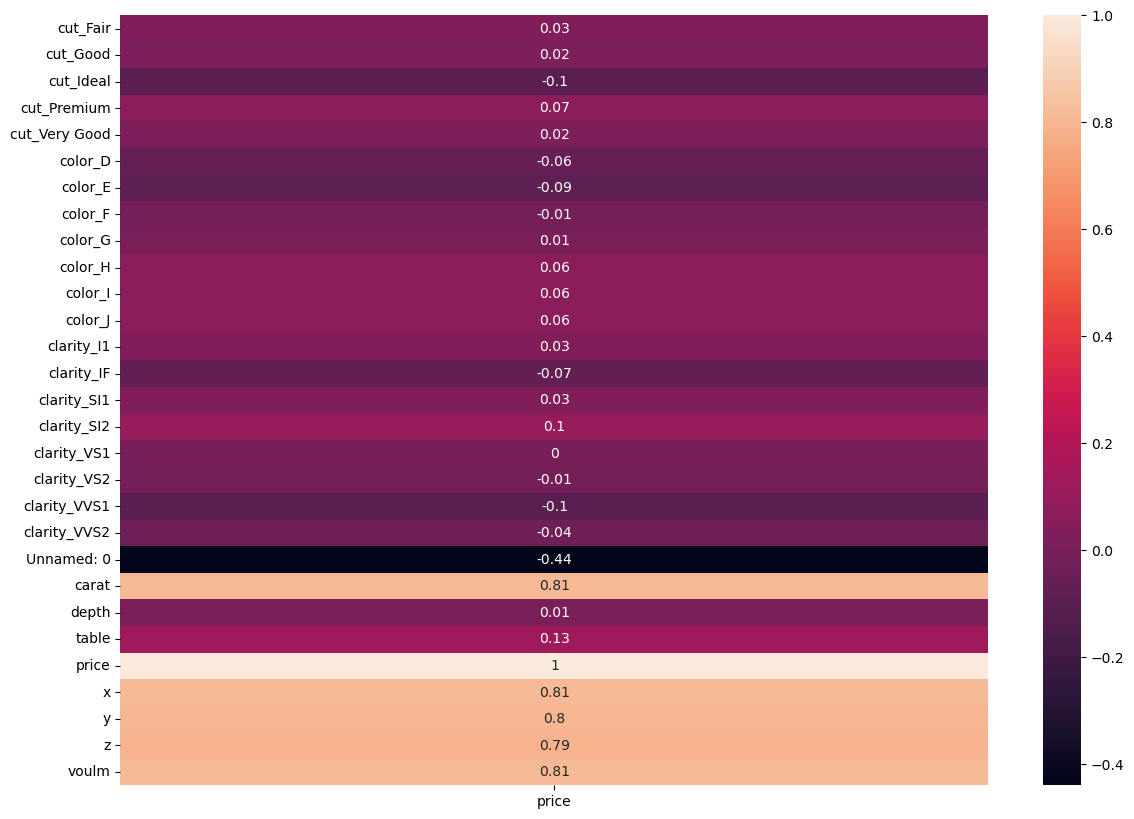

In [45]:
plt.figure(figsize=(14, 10))
correlation_matrix = df3.corr()
sns.heatmap(correlation_matrix[['price']].round(2), annot=True, fmt='g')
plt.show()


In [46]:
# Delete columns : Unnamed: 0, x, y, z
# Delete Unnamed: 0 because is unique
# Delete x,y and z because they replaced it with a new column: voulm
df3 = df3.drop(columns=['x', 'y', 'z', 'Unnamed: 0'])


In [47]:
df3.columns

Index(['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good',
       'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I',
       'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2',
       'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2', 'carat',
       'depth', 'table', 'price', 'voulm'],
      dtype='object')

# Applay Scalling

In [49]:
df4 = pd.DataFrame()
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df3)
df4 = pd.DataFrame(scaled_array, columns=df3.columns)
df4.head()

,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_D,color_E,color_F,color_G,color_H,...,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,carat,depth,table,price,voulm
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.019481,0.456140,0.224719,0.000000,0.022958
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.006494,0.157895,0.898876,0.000000,0.009891
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.019481,0.526316,0.449438,0.000086,0.022515
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.058442,0.614035,0.561798,0.000691,0.053086
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.071429,0.771930,0.561798,0.000777,0.071443


In [50]:
print(df4.describe())

           cut_Fair      cut_Good     cut_Ideal   cut_Premium  cut_Very Good  \
count  53940.000000  53940.000000  53940.000000  53940.000000   53940.000000   
mean       0.029848      0.090953      0.399537      0.255673       0.223990   
std        0.170169      0.287545      0.489808      0.436243       0.416919   
min        0.000000      0.000000      0.000000      0.000000       0.000000   
25%        0.000000      0.000000      0.000000      0.000000       0.000000   
50%        0.000000      0.000000      0.000000      0.000000       0.000000   
75%        0.000000      0.000000      1.000000      1.000000       0.000000   
max        1.000000      1.000000      1.000000      1.000000       1.000000   

            color_D       color_E       color_F       color_G       color_H  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.125603      0.181628      0.176900      0.209344      0.153949   
std        0.331404      0.385541      0.3

# Dataset split

In [52]:
X = df4.loc[:, df4.columns != 'price']
Y = df4['price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state=42)

In [53]:
X_train.columns

Index(['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good',
       'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I',
       'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2',
       'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2', 'carat',
       'depth', 'table', 'voulm'],
      dtype='object')

In [54]:
y_train.describe()

count    37758.000000
mean         0.240270
std          0.233244
min          0.000000
25%          0.054404
50%          0.157945
75%          0.361140
max          1.000000
Name: price, dtype: float64

# Applay initial DecisionTree Regaration

<P>سوف نستخدم ثلاث معايير بدون حد للعمق</P>

In [57]:
def regression_results(y_true, y_pred):

    # Regression metrics
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)

    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

In [58]:
y_train=y_train.loc[X_train.index]
y_test=y_test.loc[X_test.index]

model = DecisionTreeRegressor(criterion='poisson')  
model.fit(X_train,y_train)

some_new_data=X_test[:20]

a=y_test[:20].to_numpy()
b=model.predict(some_new_data)

pd.DataFrame([a,b,abs(a-b)],index=["Acutal","Predicted","ABS"]).T

,Acutal,Predicted,ABS
0,0.020121,0.020121,0.000000
1,0.161917,0.186356,0.024439
2,0.078756,0.071848,0.006908
3,0.084456,0.081865,0.002591
4,0.567789,0.934629,0.366839
5,0.231865,0.280570,0.048705
6,0.124266,0.132470,0.008204
7,0.116839,0.129965,0.013126
8,0.153368,0.145337,0.008031
9,0.385406,0.583161,0.197755


In [59]:
print("Train:")
print(regression_results(y_train,model.predict(X_train)))
print("Test:")
print(regression_results(y_test,model.predict(X_test)))

Train:
r2:  0.998
MAE:  0.0012
MSE:  0.0001
RMSE:  0.0104
None
Test:
r2:  0.8168
MAE:  0.0331
MSE:  0.0096
RMSE:  0.0981
None


In [60]:
y_train=y_train.loc[X_train.index]
y_test=y_test.loc[X_test.index]

model = DecisionTreeRegressor(criterion='friedman_mse')  
model.fit(X_train,y_train)

some_new_data=X_test[:20]

a=y_test[:20].to_numpy()
b=model.predict(some_new_data)

pd.DataFrame([a,b,abs(a-b)],index=["Acutal","Predicted","ABS"]).T

,Acutal,Predicted,ABS
0,0.020121,0.020121,0.000000e+00
1,0.161917,0.136097,2.582038e-02
2,0.078756,0.071848,6.908463e-03
3,0.084456,0.087047,2.590674e-03
4,0.567789,0.934629,3.668394e-01
5,0.231865,0.280570,4.870466e-02
6,0.124266,0.132470,8.203800e-03
7,0.116839,0.116408,4.317789e-04
8,0.153368,0.130829,2.253886e-02
9,0.385406,0.583161,1.977547e-01


In [61]:
print("Train:")
print(regression_results(y_train,model.predict(X_train)))
print("Test:")
print(regression_results(y_test,model.predict(X_test)))

Train:
r2:  0.998
MAE:  0.0012
MSE:  0.0001
RMSE:  0.0104
None
Test:
r2:  0.8037
MAE:  0.034
MSE:  0.0103
RMSE:  0.1016
None


In [62]:
y_train=y_train.loc[X_train.index]
y_test=y_test.loc[X_test.index]

model = DecisionTreeRegressor(criterion='squared_error')  
model.fit(X_train,y_train)

some_new_data=X_test[:20]

a=y_test[:20].to_numpy()
b=model.predict(some_new_data)

pd.DataFrame([a,b,abs(a-b)],index=["Acutal","Predicted","ABS"]).T

,Acutal,Predicted,ABS
0,0.020121,0.020121,0.000000e+00
1,0.161917,0.136097,2.582038e-02
2,0.078756,0.071848,6.908463e-03
3,0.084456,0.081865,2.590674e-03
4,0.567789,0.934629,3.668394e-01
5,0.231865,0.280570,4.870466e-02
6,0.124266,0.132470,8.203800e-03
7,0.116839,0.116408,4.317789e-04
8,0.153368,0.130829,2.253886e-02
9,0.385406,0.584974,1.995682e-01


In [63]:
print("Train:")
print(regression_results(y_train,model.predict(X_train)))
print("Test:")
print(regression_results(y_test,model.predict(X_test)))

Train:
r2:  0.998
MAE:  0.0012
MSE:  0.0001
RMSE:  0.0104
None
Test:
r2:  0.8097
MAE:  0.0338
MSE:  0.01
RMSE:  0.1
None


<p>نلاحظ الفرق في الدقه يؤدي لظهور 
<br>
overfit 
<br>
نحاول ابجاد افضل القيم لمودل الانحدار لرفع الدقه لتكون متقاربه بين التدريب والاختبار</p>

# Finding the optimal parameters of the decision tree e

# 1-Pre-pruning technique - criterion: poisson, squared_error

In [67]:
tree_params = [{'max_depth': list(range(4, 20)), 'criterion': ['poisson', 'friedman_mse', 'squared_error'] }]

clf = DecisionTreeRegressor()

clf_cv = GridSearchCV(clf, tree_params, cv = 10, scoring='neg_mean_squared_error')

clf_cv.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid=[{'criterion': ['poisson', 'friedman_mse',
                                        'squared_error'],
                          'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                        15, 16, 17, 18, 19]}],
             scoring='neg_mean_squared_error')

In [68]:
clf_cv.best_estimator_

DecisionTreeRegressor(criterion='poisson', max_depth=13)

In [100]:
#### Implementing the values
model2 = DecisionTreeRegressor(criterion='poisson', max_depth=13, random_state=0)
# fit the model
model2.fit(X_train, y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=13, random_state=0)

In [102]:
print("Train:")
print(regression_results(y_train,model2.predict(X_train)))
print("Test:")
print(regression_results(y_test,model2.predict(X_test)))

Train:
r2:  0.9025
MAE:  0.0283
MSE:  0.0053
RMSE:  0.0728
None
Test:
r2:  0.8552
MAE:  0.0346
MSE:  0.0076
RMSE:  0.0873
None


<p>We can see that the training-set score and test-set score is same as above. The training-set accuracy score is 0.9025 while the test-set accuracy to be 0.8552 These two values are quite comparable. So, there is no sign of overfitting.</p> 


# Draw Tree

[Text(0.5520328729700517, 0.9642857142857143, 'x[23] <= 0.282\npoisson = 0.103\nsamples = 37758\nvalue = 0.24'),
 Text(0.3120106374565011, 0.8928571428571429, 'x[23] <= 0.15\npoisson = 0.016\nsamples = 17857\nvalue = 0.066'),
 Text(0.17645844867130656, 0.8214285714285714, 'x[23] <= 0.1\npoisson = 0.005\nsamples = 12047\nvalue = 0.039'),
 Text(0.08566398423494674, 0.75, 'x[23] <= 0.06\npoisson = 0.004\nsamples = 8077\nvalue = 0.032'),
 Text(0.032685133923863754, 0.6785714285714286, 'x[20] <= 0.029\npoisson = 0.003\nsamples = 1377\nvalue = 0.02'),
 Text(0.013590108615417063, 0.6071428571428571, 'x[17] <= 0.5\npoisson = 0.002\nsamples = 380\nvalue = 0.014'),
 Text(0.007777074765369609, 0.5357142857142857, 'x[16] <= 0.5\npoisson = 0.002\nsamples = 326\nvalue = 0.015'),
 Text(0.003216281767373194, 0.4642857142857143, 'x[23] <= 0.017\npoisson = 0.001\nsamples = 282\nvalue = 0.016'),
 Text(0.000843614889802805, 0.39285714285714285, 'x[23] <= 0.011\npoisson = 0.001\nsamples = 4\nvalue = 0.003'

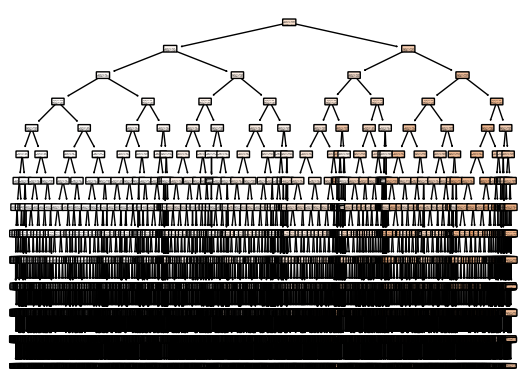

In [106]:
plot_tree(model2,filled=True,rounded=True)

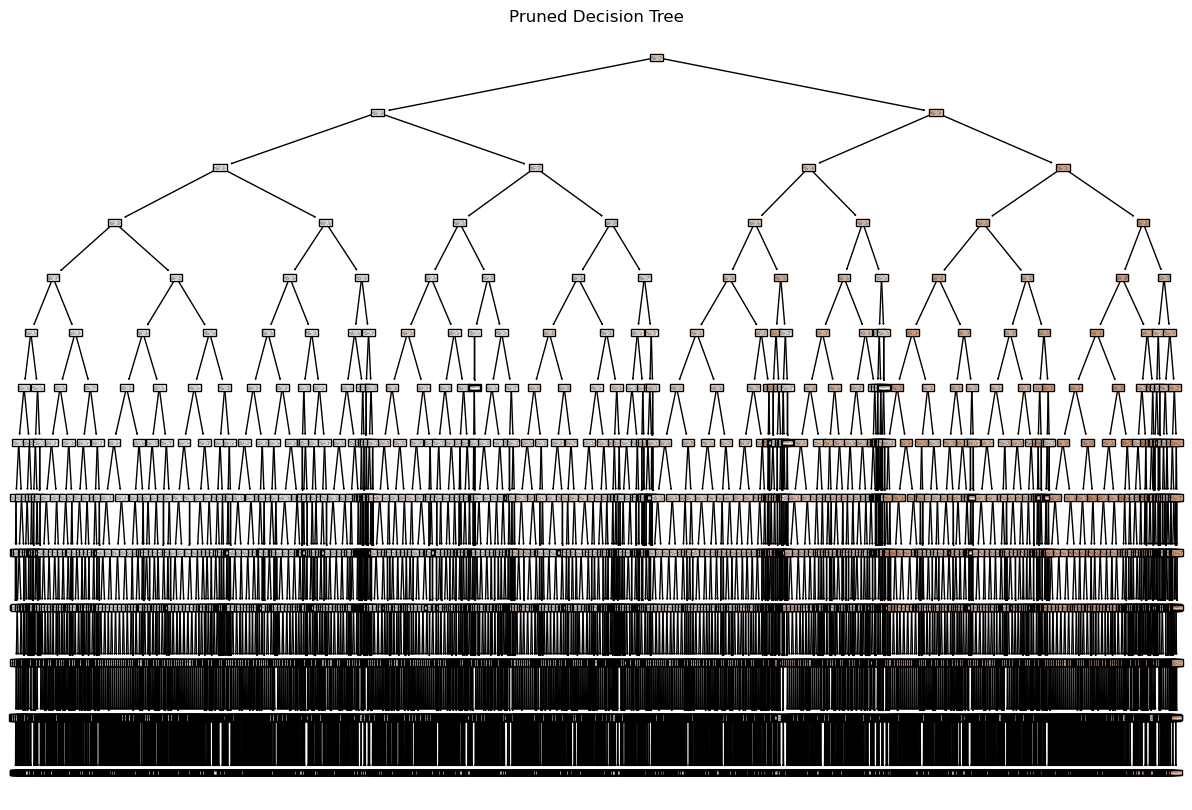

In [107]:
# Plot pruned tree
plt.figure(figsize=(15, 10))
plot_tree(model2, filled=True)
plt.title("Pruned Decision Tree")
plt.show()